# Binary Search Tree Network

### Imports

In [2]:
import sys
sys.path.append("..")

from networks.bst_network import BinarySearchTreeNetwork
from visualization.graph_visualization import plot_tree

### Empty Network

In [3]:
network = BinarySearchTreeNetwork()

assert network.root is None
assert network.total_communication_cost == 0

### Insert Root

In [4]:
network = BinarySearchTreeNetwork()

node = network.insert(10)

assert network.root == node
assert node.key == 10
assert node.parent is None

### BST Structure

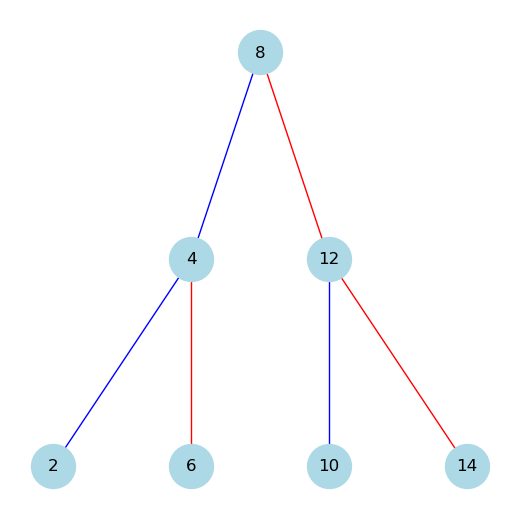

In [6]:
network = BinarySearchTreeNetwork()

network = BinarySearchTreeNetwork()

for key in [8, 4, 12, 2, 6, 10, 14]:
    network.insert(key)

assert network.root.key == 8

assert network.root.left.key == 4
assert network.root.right.key == 12

assert network.root.left.left.key == 2
assert network.root.left.right.key == 6

assert network.root.right.left.key == 10
assert network.root.right.right.key == 14

plot_tree(network)

### Search in the Network

In [7]:
node, depth = network.search(10)

assert node.key == 10
assert depth == 2

node, depth = network.search(2)

assert node.key == 2
assert depth == 2

node, depth = network.search(99)

assert node is None

### LCA

In [8]:
lca, depth = network.least_common_ancestor(2, 6)

assert lca.key == 4
assert depth == 1

lca, depth = network.least_common_ancestor(2, 14)

assert lca.key == 8
assert depth == 0

lca, depth = network.least_common_ancestor(4, 6)

assert lca.key == 4
assert depth == 1

### Communication

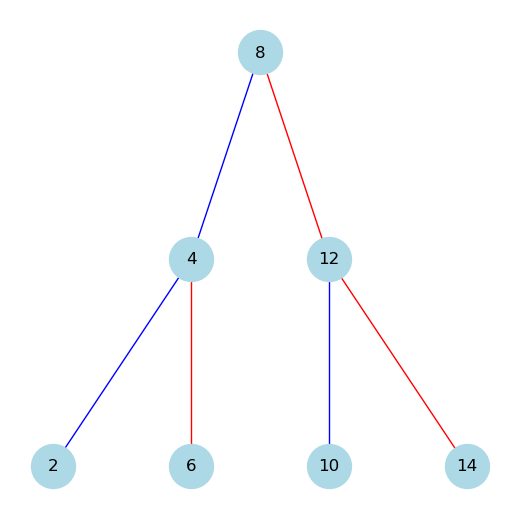

In [10]:
plot_tree(network)

In [12]:
network = BinarySearchTreeNetwork()

for key in [8, 4, 12, 2, 6, 10, 14]:
    network.insert(key)

u, v, lca = network.request(2, 6)

assert u.key == 2
assert v.key == 6
assert lca.key == 4

assert network.total_communication_cost == 2

In [13]:
network = BinarySearchTreeNetwork()

for key in [8, 4, 12, 2, 6, 10, 14]:
    network.insert(key)

network.request(2, 6)      # 2
network.request(2, 14)     # 4
network.request(10, 14)    # 2

assert network.total_communication_cost == 8

# SplayNet

### Imports

In [1]:
import sys
sys.path.append("..")

from networks.splaynet import SplayNet
from visualization.graph_visualization import plot_tree

### Insert

In [2]:
net = SplayNet()

for key in [10, 5, 15, 3, 7, 12, 20]:
    net.insert(key)

assert net.root.key == 10

assert net.root.left.key == 5
assert net.root.right.key == 15

assert net.root.left.left.key == 3
assert net.root.left.right.key == 7

assert net.root.right.left.key == 12
assert net.root.right.right.key == 20

### Search

In [3]:
net = SplayNet()

for key in [10, 5, 15, 3, 7]:
    net.insert(key)

assert net.search(10).key == 10
assert net.search(5).key == 5
assert net.search(7).key == 7

assert net.search(999) is None

### LCA

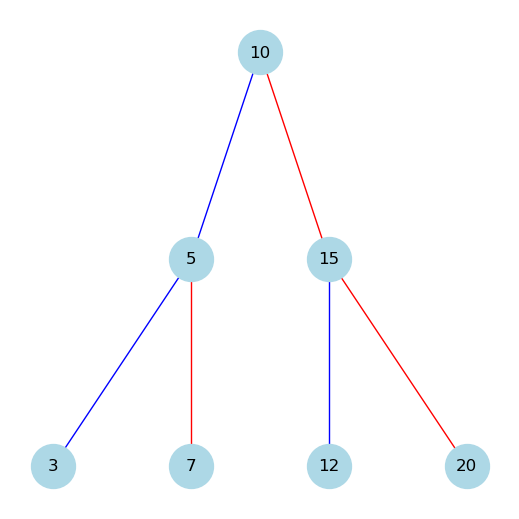

In [ ]:
net = SplayNet()

for key in [10, 5, 15, 3, 7, 12, 20]:
    net.insert(key)

plot_tree(net)

In [8]:
lca  = net.least_common_ancestor(3, 7)
assert lca.key == 5

lca = net.least_common_ancestor(3, 20)
assert lca.key == 10

lca = net.least_common_ancestor(12, 20)
assert lca.key == 15

lca = net.least_common_ancestor(12, 15)
assert lca.key == 15

### Right Rotation

In [9]:
net = SplayNet()

for key in [10, 5, 3]:
    net.insert(key)

node = net.search(5)

net.rotate_right(node)

assert net.root.key == 5

assert net.root.left.key == 3
assert net.root.right.key == 10

assert net.root.left.parent is net.root
assert net.root.right.parent is net.root

### Left Rotation

In [10]:
net = SplayNet()

for key in [10, 15, 20]:
    net.insert(key)

node = net.search(15)

net.rotate_left(node)

assert net.root.key == 15

assert net.root.left.key == 10
assert net.root.right.key == 20

assert net.root.left.parent is net.root
assert net.root.right.parent is net.root

print("Left rotation test passed")

Left rotation test passed


### Request - LCA is the Root

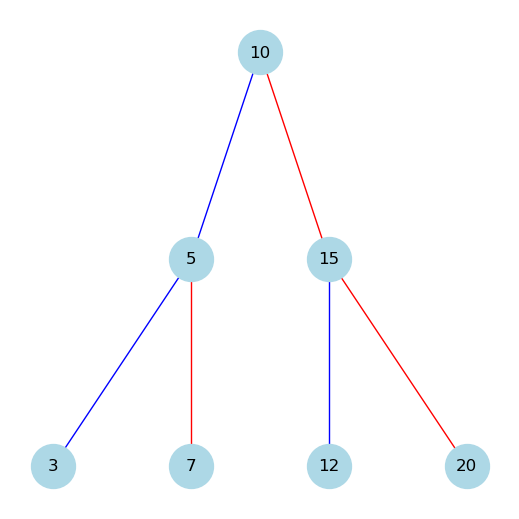

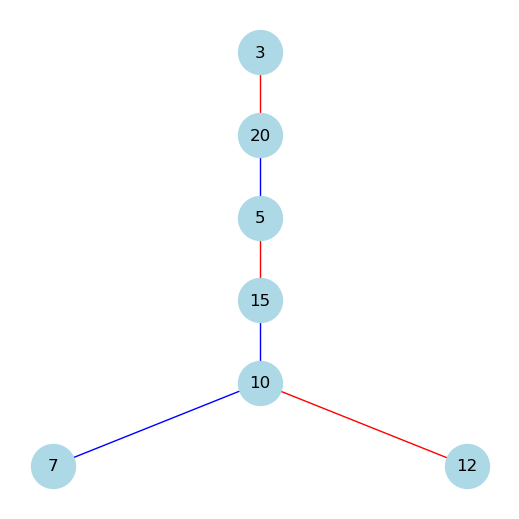

In [11]:
net = SplayNet()

for key in [10, 5, 15, 3, 7, 12, 20]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(3, 20)

assert s.key == 3
assert t.key == 20
assert lca.key == 10

assert net.root.key == 3

plot_tree(net)

### Request - LCA is the Sender

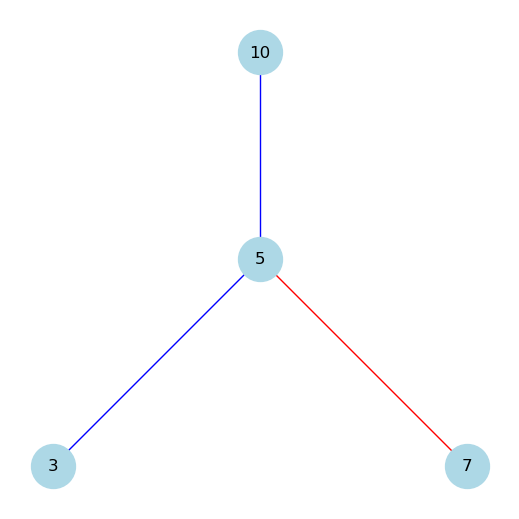

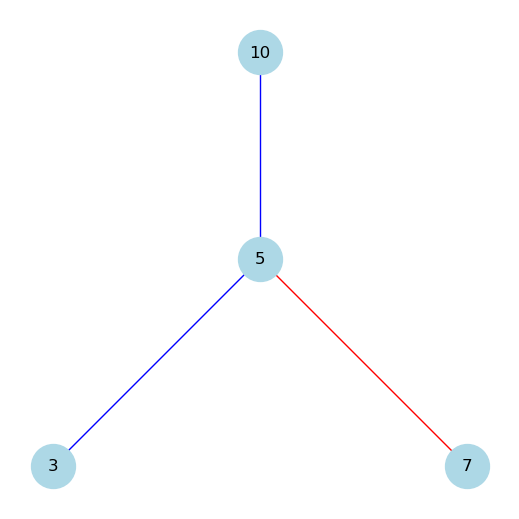

In [12]:
net = SplayNet()

for key in [10, 5, 3, 7]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(5, 3)

assert s.key == 5
assert t.key == 3
assert lca.key == 5

plot_tree(net)

### Request - LCA is the Receiver

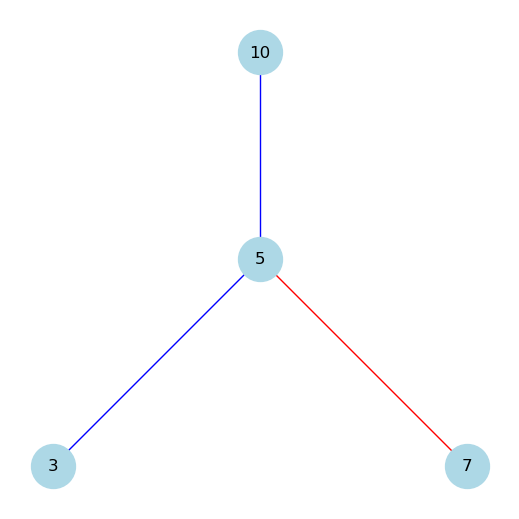

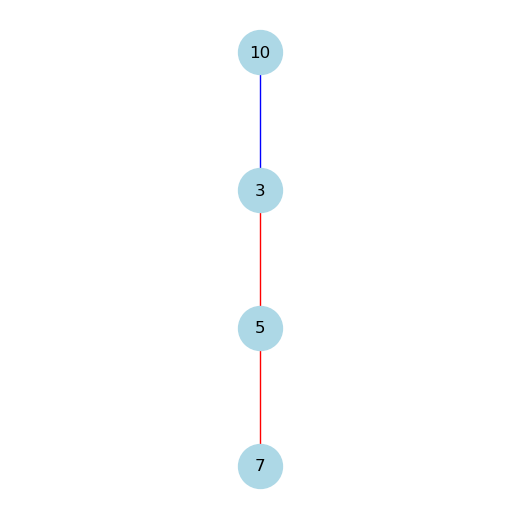

In [14]:
net = SplayNet()

for key in [10, 5, 3, 7]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(3, 5)

assert s.key == 3
assert t.key == 5
assert lca.key == 5

plot_tree(net)

### Request - Both Nodes in Left Subtree

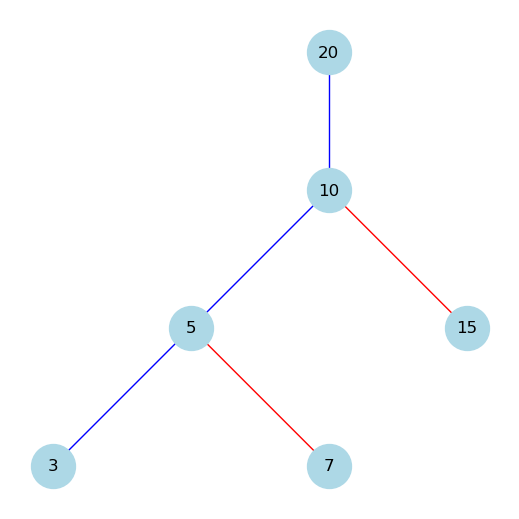

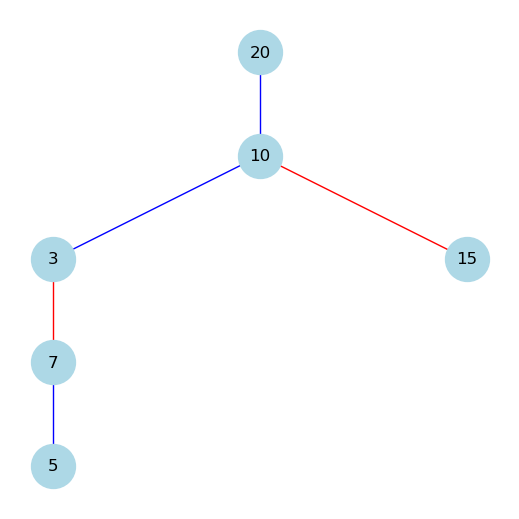

In [15]:
net = SplayNet()

for key in [20, 10, 5, 15, 3, 7]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(3, 7)

assert s.key == 3
assert t.key == 7
assert lca.key == 5

plot_tree(net)

### Rotation Counter

In [23]:
net = SplayNet()

for key in [10, 5, 15, 3, 20]:
    net.insert(key)

assert net.total_communication_cost == 0
assert net.rotations == 0 

net.request(3, 20)
assert net.rotations == 5
assert net.total_communication_cost == 1

In [ ]:
net = SplayNet()

for key in [20, 10, 5, 3, 7]:
    net.insert(key)

net.request(3, 7)

assert net.rotations ==  2
assert net.total_communication_cost == 1

In [26]:
net = SplayNet()

for key in [20, 10, 5, 3, 7]:
    net.insert(key)

for _ in range(10):
    net.request(3, 7)

assert net.rotations ==  2
assert net.total_communication_cost == 10